<a href="https://colab.research.google.com/github/XaVIIIerg/deep-learning-nlp-coursework/blob/main/deep-learning/softmax_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

For installing torchsummary use `pip install torchsummary`

In [ ]:
pip install torchsummary

Note: you may need to restart the kernel to use updated packages.


In [ ]:
from datetime import datetime
import torch
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
from torchsummary import summary
import matplotlib.pyplot as plt

## Multinomial Classification of MNIST

1. Load the MNIST dataset by clicking through the first cells and see how to depict some samples. Please note that a training and a test dataset are loaded. Make sure that only the training set will be used for training and the test dataset just for evaluation (accuracy).
2. Implement the multinomial logistic regression model by completing the code in the functions $\verb|linear_trsf|$, $\verb|softmax|$, $\verb|predict|$, $\verb|loss_ce|$, $\verb|cost_ce|$.
3. Implement the mini-batch gradient descent training loop configured by number of epochs, batch size and learning rate. Implement the gradient explicitly (without autograd). Train the model with $\verb|nepochs=10|$, $\verb|nbatch=64|$ and $\verb|lr=0.01|$.
4. Tune learning rate and batch size and qualitatively characterise the behaviour. What is your favorite combination (learning rate, batch size, number of epochs)
5. Build and train the model with full-fledge pytorch incl. autograd. Implement a model class inheriting from $torch.nn.Module$ and use the layer functionality in the package $torch.nn$ (see lecture). Prove that you obtain the same accuracy.


#### Hints
* Keep an eye on the shapes of the tensors (as passed into the functions and as used within the functions (and declared in the function descriptions).
* For each implemented function, run a small test with dummy input tensors (of the required shape) and check whether it outputs a tensor with expected shape and no 'nan'.
* Possibly, add $\verb|assert()|$ statements in the code.
* For the training loop perform a training with only a single batch of size 64. Here, you should be able to obtain 100% training accuracy.

### 1. Loading the Data

Click through the cells below to load the MNIST dataset and learn how to access its samples.

#### Dataset

In [ ]:
training_data = datasets.MNIST(
    root="../data",
    train=True,
    download=True,
    transform=ToTensor()
)
test_data = datasets.MNIST(
    root="../data",
    train=False,
    download=True,
    transform=ToTensor()
)

In [ ]:
print(training_data)

Dataset MNIST
    Number of datapoints: 60000
    Root location: ../data
    Split: Train
    StandardTransform
Transform: ToTensor()


In [ ]:
print(training_data.data.shape)

torch.Size([60000, 28, 28])


In [ ]:
print(test_data.data.shape)

torch.Size([10000, 28, 28])


In [ ]:
print(len(training_data))
x, y = training_data[5]
print(type(x), x.shape, x.dtype)
print(type(y), y)

60000
<class 'torch.Tensor'> torch.Size([1, 28, 28]) torch.float32
<class 'int'> 2


#### Depict samples

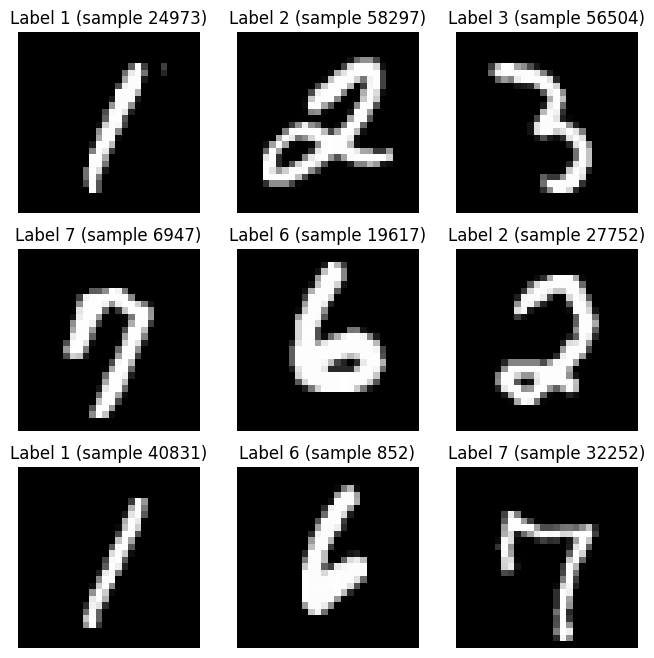

In [ ]:
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title("Label %i (sample %i)"%(label,sample_idx))
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

#### Data Loader (see lecture)

In [ ]:
train_dataloader = DataLoader(training_data, batch_size=64, shuffle=True)

In [ ]:
data_train, labels_train = next(iter(train_dataloader))
print(f"Feature batch shape: {data_train.shape}")
print(f"Labels batch shape: {labels_train.shape}")

Feature batch shape: torch.Size([64, 1, 28, 28])
Labels batch shape: torch.Size([64])


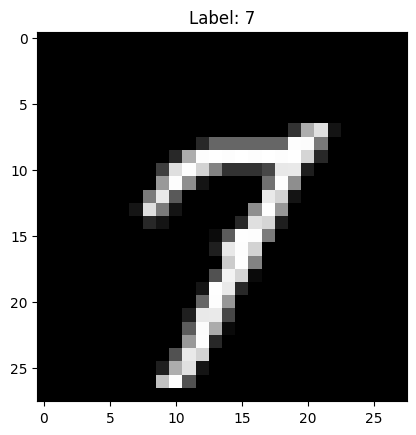

In [ ]:
img = data_train[0].squeeze()
label = labels_train[0]
plt.imshow(img, cmap="gray")
plt.title(f"Label: {label}")
plt.show()

### 2. Multinomial Logistic Regression

Now, implement the model, i.e. multinomial logistic regression and the loss/cost function (cross-entropy cost).

To that end, implement the python functions below.
All arguments are pytorch tensors with indicated shapes.

In [ ]:
def linear_trsf(x,W,b):
    """
    x -- tensor with shape (nb,1,28,28)
    W -- tensor with shape (10,28*28)
    b -- tensor with shape (1,10)
    """
    # YOUR CODE (START)
    nb = x.shape[0]
    x1 = x.view(nb, -1)
    lin_trsf = x1 @ W.T + b
    return lin_trsf
    # YOUR CODE (END)

def softmax(z):
    """
    z -- tensor of shape (nb,10)
    """
    # YOUR CODE (START)
    e = torch.exp(z)
    soft = e / torch.sum(e, dim = 1, keepdim = True)
    return soft
    # YOUR CODE (END)

def predict(x,W,b):
    """
    x -- tensor with shape (nb,1,28,28)
    W -- tensor with shape (10,28*28)
    b -- tensor with shape (1,10)
    """
    # YOUR CODE (START)
    output = linear_trsf(x, W, b)
    proba = softmax(output)
    return proba
    # YOUR CODE (END)


##### TEST

In [ ]:
W,b = torch.randn((10,28*28)), torch.zeros((1,10))
print(W.shape,b.shape)
u = predict(x,W,b)
print(u.shape, torch.sum(u).item())

torch.Size([10, 784]) torch.Size([1, 10])
torch.Size([1, 10]) 1.0


#### Loss Function

In [ ]:
def loss_ce(y, uhat):
    """
    y -- tensor with shape (nb,1) and possible values (0,1,2,3,4,5,6,7,8,9)
    uhat -- tensor with shape (nb,10)
    returns -- per sample loss
    """
    # YOUR CODE (START)
    N = y.shape[0]
    return -torch.log(uhat[torch.arange(N), y[:]])
    # YOUR CODE (END)

def cost_ce(y,uhat):
    """
    y -- tensor with shape (nb,1) and possible values (0,1,2,3,4,5,6,7,8,9)
    uhat -- tensor with shape (nb,10)
    return -- per batch mean of losses
    """
    # YOUR CODE (START)
    return torch.mean(loss_ce(y,uhat))
    # YOUR CODE (END)


##### TEST

In [ ]:
import numpy as np
y = torch.tensor([0,2])
z = torch.tensor([[1.,2,3],[2,2,2]]).reshape(-1,3)
uhat = softmax(z)
print(loss_ce(y,uhat), cost_ce(y,uhat))

tensor([2.4076, 1.0986]) tensor(1.7531)


### 3. Mini-Batch Gradient Descent

For the training, we adopt gradient descent - and start with the implementation of the gradient of the cost function (cross-entropy cost function).  

#### Gradient

In [ ]:
def grad_loss_ce(x,u,uhat):
    """
    x -- tensor with shape (nb,1, 28*28)
    u -- tensor with shape (nb,10)  # 10 because there are 10 possible labels
    uhat -- tensor with shape (nb,10)
    returns -- gradW, gradb (same dimension as W and b)
    """
    # YOUR CODE (START)
    gradW = torch.mean((uhat - u).view(-1, 10, 1) * x.view(-1, 1, 28*28), dim = 0)
    gradb = torch.mean((uhat - u), dim = 0)
    return gradW, gradb
    # YOUR CODE (END)

#### Metrics - Cost, Accuracy

For tracking the progress of the training, we will use two functions: the cost and the accuracy.

In [ ]:
def metrics(X,Y,W,b):
    """
    X -- tensor with shape (nb,1,28*28)
    Y -- tensor with shape (nb,10)
    W -- tensor with shape (10,28*28)
    b -- tensor with shape (10,1)

    return -- cost, acc (both scalars)
    """
    # YOUR CODE (START)
    uhat = predict(X, W, b)
    cost = cost_ce(Y, uhat)
    predicted = torch.argmax(uhat, dim = 1)
    correct = (predicted == Y).sum().item()
    acc = correct/ len(Y) * 100
    return cost, acc
    # YOUR CODE (END)

#### Training

In [ ]:
def training(nepochs, alpha, nclasses, nbatch) :
    # a function has been created to ease the comparison between the different values of the parameters
    cost_hist = []
    acc_hist = []
    cost_hist_test = []
    acc_hist_test = []

    # data loaders
    train_dataloader = DataLoader(training_data, batch_size=nbatch, shuffle=True)
    test_dataloader = DataLoader(test_data, batch_size=10000, shuffle=True)

    # test data - we can load all samples for the test since it easily fits into memory
    Xtest,Ytest = next(iter(test_dataloader))

    # initial parameters
    W,b = torch.randn((10,28*28)), torch.zeros((1,nclasses))

    d0 = datetime.now()

    for epoch in range(nepochs):
        cost = 0.0
        acc = 0
        for X,Y in train_dataloader:
            uhat = predict(X, W, b)

            # we have to flatten X for the grad loss (because we need (nb,1, 28*28))
            X_flatten = X.view(X.shape[0], -1)

            # we need to one hot encode Y for the grad loss (because we need (nb,10))
            Y_one_hot = torch.nn.functional.one_hot(Y, nclasses).float()

            dW, db = grad_loss_ce(X_flatten, Y_one_hot, uhat)

            W = W - alpha * dW
            b = b - alpha * db

            cost_batch, acc_batch = metrics(X, Y, W, b)
            cost += cost_batch.item() * X.shape[0]
            acc  += int(acc_batch * X.shape[0] / 100.0)

        cost /= len(training_data)
        acc = acc / len(training_data) * 100.0
        cost_test, acc_test = metrics(Xtest, Ytest, W, b)

        cost_hist.append(cost)
        acc_hist.append(acc)
        cost_hist_test.append(cost_test.item())
        acc_hist_test.append(acc_test)

        print("Epoch %i: , cost : %f, acc : %f, cost_test :  %f, acc_test : %f"%(epoch, cost, acc, cost_test, acc_test))

    return d0, cost_hist, acc_hist, cost_hist_test, acc_hist_test

In [ ]:
d0, cost_hist, acc_hist, cost_hist_test, acc_hist_test = training(10, 0.1, 10, 64)

d = datetime.now()
print("runing time :", (d-d0).total_seconds()/10)

Epoch 0: , cost : 2.055424, acc : 66.086667, cost_test :  0.965221, acc_test : 79.970000
Epoch 1: , cost : 0.836928, acc : 82.218333, cost_test :  0.727193, acc_test : 84.250000
Epoch 2: , cost : 0.681261, acc : 84.973333, cost_test :  0.638019, acc_test : 86.050000
Epoch 3: , cost : 0.603798, acc : 86.475000, cost_test :  0.582573, acc_test : 86.620000
Epoch 4: , cost : 0.553456, acc : 87.378333, cost_test :  0.545916, acc_test : 87.600000
Epoch 5: , cost : 0.518843, acc : 87.880000, cost_test :  0.517175, acc_test : 88.030000
Epoch 6: , cost : 0.490752, acc : 88.360000, cost_test :  0.497977, acc_test : 88.310000
Epoch 7: , cost : 0.469677, acc : 88.705000, cost_test :  0.479872, acc_test : 88.680000
Epoch 8: , cost : 0.451416, acc : 89.073333, cost_test :  0.466384, acc_test : 88.900000
Epoch 9: , cost : 0.436144, acc : 89.338333, cost_test :  0.455615, acc_test : 89.120000
runing time : 7.4916838


        The accuracy improves as the epoch progress, while the cost decreases. The running time isn't negligible though.

Text(0.5, 1.0, 'Accuracy')

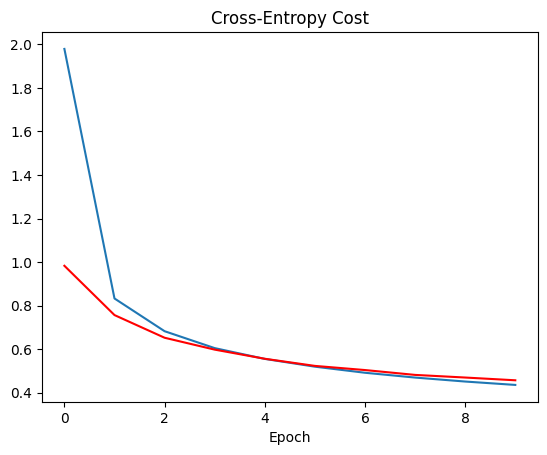

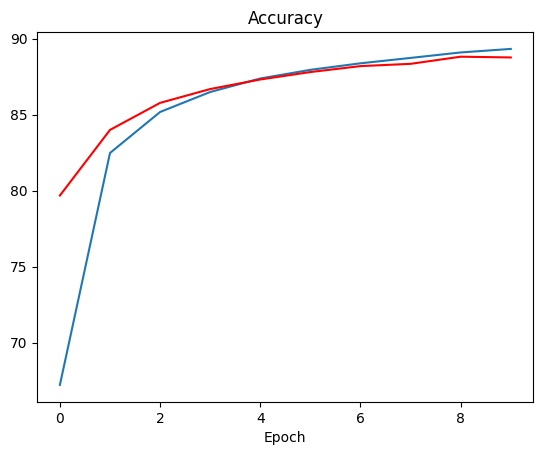

In [ ]:
plt.figure(1)
plt.plot(torch.arange(10), cost_hist, "-")
plt.plot(torch.arange(10), cost_hist_test, "r-")
plt.xlabel("Epoch")
plt.title("Cross-Entropy Cost")
plt.figure(2)
plt.plot(torch.arange(10), acc_hist,"-")
plt.plot(torch.arange(10), acc_hist_test,"r-")
plt.xlabel("Epoch")
plt.title("Accuracy")

    Test and train are following the same trends.

### 4. Tune learning rate and batch size

Now analyse the training progress with five, well selected settings for each, the learning rate and the batch size.
Make sure that for each setting, a more or less "stable" test performance is achieved, i.e. a status where the test accurace is no longer expected to improve. Choose the number of epochs accordingly.

Finally, prepare suitable plots and tables to make the comparison transparent and characterize in words what you observe.

Explain the behavior.

    1. Tunning the learning rate

In [ ]:
# order of the parameters : nepochs, learning rate, nclasses (no changes), nbatch
# First case
d0, cost_hist1, acc_hist1, cost_hist_test1, acc_hist_test1 = training(10, 0.001, 10, 64)

# Seconde case
d0, cost_hist2, acc_hist2, cost_hist_test2, acc_hist_test2 = training(10, 0.01, 10, 64)

# Third case
d0, cost_hist3, acc_hist3, cost_hist_test3, acc_hist_test3 = training(10, 0.1, 10, 64)

# Fourth case
d0, cost_hist4, acc_hist4, cost_hist_test4, acc_hist_test4 = training(10, 1, 10, 64)

# Fifth case
d0, cost_hist5, acc_hist5, cost_hist_test5, acc_hist_test5 = training(10, 10, 10, 64)

Text(0.5, 1.0, 'Accuracy')

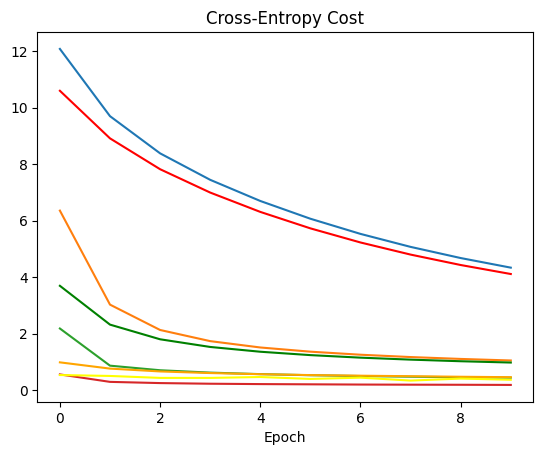

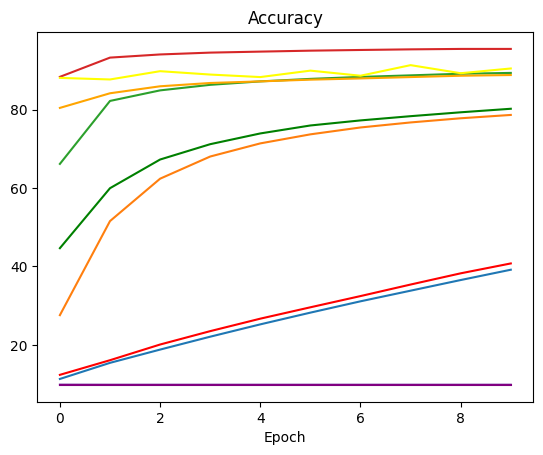

In [ ]:
# Plots
plt.figure(1)
plt.plot(torch.arange(10), cost_hist1, "-")
plt.plot(torch.arange(10), cost_hist_test1, "red")
plt.plot(torch.arange(10), cost_hist2, "-")
plt.plot(torch.arange(10), cost_hist_test2, "green")
plt.plot(torch.arange(10), cost_hist3, "-")
plt.plot(torch.arange(10), cost_hist_test3, "orange")
plt.plot(torch.arange(10), cost_hist4, "-")
plt.plot(torch.arange(10), cost_hist_test4, "yellow")
plt.plot(torch.arange(10), cost_hist5, "-")
plt.plot(torch.arange(10), cost_hist_test5, "purple")
plt.xlabel("Epoch")
plt.title("Cross-Entropy Cost")
plt.figure(2)
plt.plot(torch.arange(10), acc_hist1,"-")
plt.plot(torch.arange(10), acc_hist_test1,"red")
plt.plot(torch.arange(10), acc_hist2,"-")
plt.plot(torch.arange(10), acc_hist_test2,"green")
plt.plot(torch.arange(10), acc_hist3,"-")
plt.plot(torch.arange(10), acc_hist_test3,"orange")
plt.plot(torch.arange(10), acc_hist4,"-")
plt.plot(torch.arange(10), acc_hist_test4,"yellow")
plt.plot(torch.arange(10), acc_hist5,"-")
plt.plot(torch.arange(10), acc_hist_test5,"purple")
plt.xlabel("Epoch")
plt.title("Accuracy")

    The orange line seems to be best trade-off. The cross-entropy cost well decrease while the accuracy tends to 80% for the test. For the following tunning, we will keep learning rate equal to 0.1.

    2. Tunning the number of epoch

In [ ]:
# order of the parameters : nepochs, learning rate, nclasses (no changes), nbatch
# First case
d0, cost_hist1, acc_hist1, cost_hist_test1, acc_hist_test1 = training(5, 0.1 , 10, 64)

# Seconde case
d0, cost_hist2, acc_hist2, cost_hist_test2, acc_hist_test2 = training(10, 0.1, 10, 64)

# Third case
d0, cost_hist3, acc_hist3, cost_hist_test3, acc_hist_test3 = training(50, 0.1, 10, 64)

# Fourth case
d0, cost_hist4, acc_hist4, cost_hist_test4, acc_hist_test4 = training(100, 0.1, 10, 64)

# Fifth case
d0, cost_hist5, acc_hist5, cost_hist_test5, acc_hist_test5 = training(150, 0.1, 10, 64)

Text(0.5, 1.0, 'Accuracy')

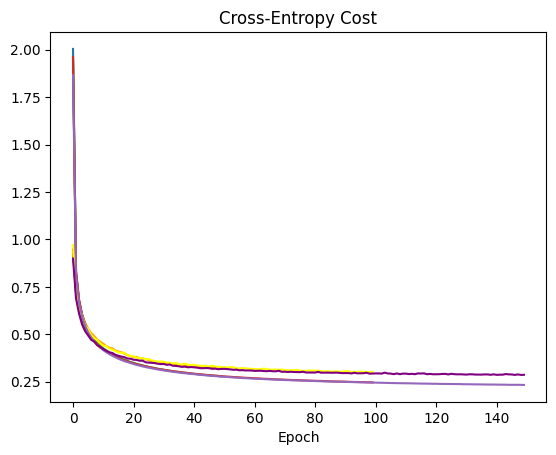

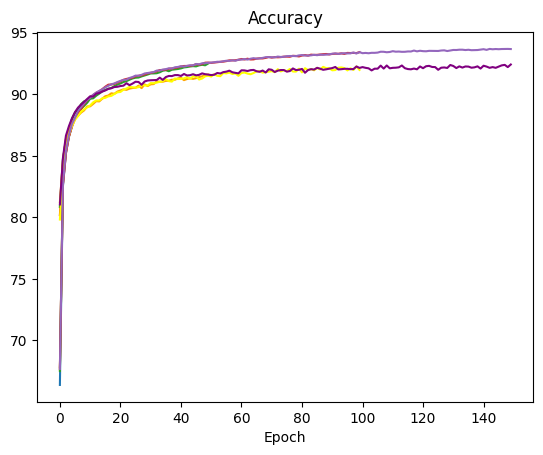

In [ ]:
# Plots
plt.figure(1)
plt.plot(torch.arange(5), cost_hist1, "-")
plt.plot(torch.arange(5), cost_hist_test1, "red")
plt.plot(torch.arange(10), cost_hist2, "-")
plt.plot(torch.arange(10), cost_hist_test2, "green")
plt.plot(torch.arange(50), cost_hist3, "-")
plt.plot(torch.arange(50), cost_hist_test3, "orange")
plt.plot(torch.arange(100), cost_hist4, "-")
plt.plot(torch.arange(100), cost_hist_test4, "yellow")
plt.plot(torch.arange(150), cost_hist5, "-")
plt.plot(torch.arange(150), cost_hist_test5, "purple")
plt.xlabel("Epoch")
plt.title("Cross-Entropy Cost")
plt.figure(2)
plt.plot(torch.arange(5), acc_hist1,"-")
plt.plot(torch.arange(5), acc_hist_test1,"red")
plt.plot(torch.arange(10), acc_hist2,"-")
plt.plot(torch.arange(10), acc_hist_test2,"green")
plt.plot(torch.arange(50), acc_hist3,"-")
plt.plot(torch.arange(50), acc_hist_test3,"orange")
plt.plot(torch.arange(100), acc_hist4,"-")
plt.plot(torch.arange(100), acc_hist_test4,"yellow")
plt.plot(torch.arange(150), acc_hist5,"-")
plt.plot(torch.arange(150), acc_hist_test5,"purple")
plt.xlabel("Epoch")
plt.title("Accuracy")

    The plot aren't at the same scale so it's difficult to compare very differents number of epoch. However, it's seem obvious that a too large nepoch is useless and significantly increases the calculation time. For the following tunning, we will keep 10, like the example of the lesson (10).

    3. Tunning the number of batch

In [ ]:
# order of the parameters : nepochs, learning rate, nclasses (no changes), nbatch
# First case
d0, cost_hist1, acc_hist1, cost_hist_test1, acc_hist_test1 = training(10, 0.1, 10, 5)

# Seconde case
d0, cost_hist2, acc_hist2, cost_hist_test2, acc_hist_test2 = training(10, 0.1, 10, 10)

# Third case
d0, cost_hist3, acc_hist3, cost_hist_test3, acc_hist_test3 = training(10, 0.1, 10, 50)

# Fourth case
d0, cost_hist4, acc_hist4, cost_hist_test4, acc_hist_test4 = training(10, 0.1, 10, 100)

# Fifth case
d0, cost_hist5, acc_hist5, cost_hist_test5, acc_hist_test5 = training(10, 0.1, 10, 500)

Text(0.5, 1.0, 'Accuracy')

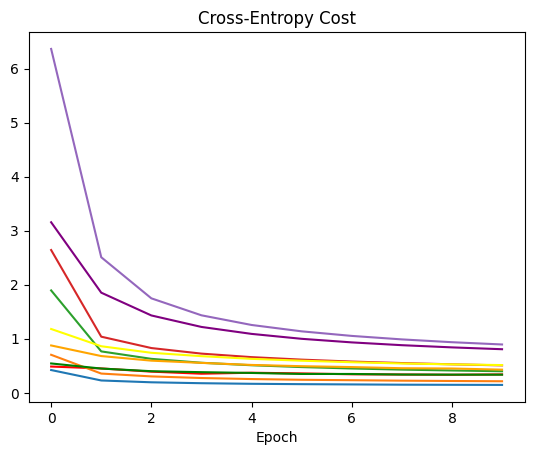

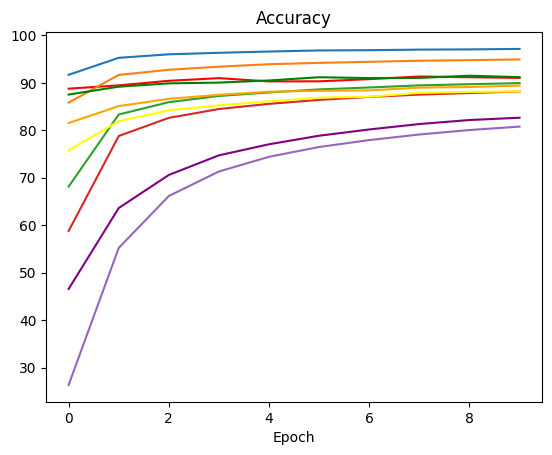

In [ ]:
# Plots
plt.figure(1)
plt.plot(torch.arange(10), cost_hist1, "-")
plt.plot(torch.arange(10), cost_hist_test1, "red")
plt.plot(torch.arange(10), cost_hist2, "-")
plt.plot(torch.arange(10), cost_hist_test2, "green")
plt.plot(torch.arange(10), cost_hist3, "-")
plt.plot(torch.arange(10), cost_hist_test3, "orange")
plt.plot(torch.arange(10), cost_hist4, "-")
plt.plot(torch.arange(10), cost_hist_test4, "yellow")
plt.plot(torch.arange(10), cost_hist5, "-")
plt.plot(torch.arange(10), cost_hist_test5, "purple")
plt.xlabel("Epoch")
plt.title("Cross-Entropy Cost")
plt.figure(2)
plt.plot(torch.arange(10), acc_hist1,"-")
plt.plot(torch.arange(10), acc_hist_test1,"red")
plt.plot(torch.arange(10), acc_hist2,"-")
plt.plot(torch.arange(10), acc_hist_test2,"green")
plt.plot(torch.arange(10), acc_hist3,"-")
plt.plot(torch.arange(10), acc_hist_test3,"orange")
plt.plot(torch.arange(10), acc_hist4,"-")
plt.plot(torch.arange(10), acc_hist_test4,"yellow")
plt.plot(torch.arange(10), acc_hist5,"-")
plt.plot(torch.arange(10), acc_hist_test5,"purple")
plt.xlabel("Epoch")
plt.title("Accuracy")

    The better trade-off between the accuracy and the cost seems to be nbatch = 5 which have a very good accuracy and the lowest cost. A small nbacth allow to well generalize the rules that have been learned.

### 5. With Full-Fledge PyTorch

In [ ]:
class NeuralNetwork(torch.nn.Module):

    def __init__(self):
        super(NeuralNetwork, self).__init__()
        self.flatten = torch.nn.Flatten()
        self.linear  = torch.nn.Linear(28*28, 10)

    def forward(self, x):
        z = self.linear(self.flatten(x))
        return z


In [ ]:
model = NeuralNetwork()
print(model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear): Linear(in_features=784, out_features=10, bias=True)
)


In [ ]:
summary(model, (1,28,28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                  [-1, 784]               0
            Linear-2                   [-1, 10]           7,850
Total params: 7,850
Trainable params: 7,850
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 0.03
Estimated Total Size (MB): 0.04
----------------------------------------------------------------


In [ ]:
nbatch = 64
nepochs = 10
learning_rate = 0.01

cost_hist = []
cost_hist_test = []
acc_hist = []
acc_hist_test = []

model = NeuralNetwork()
cost_ce_nn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

training_loader = DataLoader(training_data, batch_size=nbatch, shuffle=True)
test_loader = DataLoader(test_data, batch_size=len(test_data), shuffle=False)
Xtest, Ytest = next(iter(test_loader))

for epoch in range(nepochs):
    model.train() # training mode
    cost = 0.0
    acc = 0

    for batch, (X, Y) in enumerate(training_loader):
        pred = model(X)
        loss = cost_ce_nn(pred, Y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        cost += loss.item() * X.size(0)
        acc += (torch.argmax(pred, dim=1) == Y).sum().item()

    cost /= len(training_loader.dataset)
    acc /= len(training_loader.dataset) * 100

    model.eval() # test mode
    test_cost = 0.0
    test_acc = 0
    with torch.no_grad(): # Disable gradient calculations for test
        pred_test = model(Xtest)
        test_loss = cost_ce_nn(pred_test, Ytest)
        test_cost = test_loss.item()

        test_acc = (torch.argmax(pred_test, dim=1) == Ytest).sum().item()
    test_acc /= len(Ytest) * 100

    cost_hist.append(cost)
    acc_hist.append(acc)
    cost_hist_test.append(test_cost)
    acc_hist_test.append(test_acc)

    print(f"Epoch {epoch}: {cost}, {acc}, {test_cost}, {test_acc}")


Epoch 0: 0.98692936779658, 0.008029333333333333, 0.6000687479972839, 0.008685
Epoch 1: 0.5508863496462504, 0.008686333333333334, 0.4755210876464844, 0.008839
Epoch 2: 0.4711994907061259, 0.008795833333333333, 0.4257448613643646, 0.008913
Epoch 3: 0.4325278874079386, 0.0088635, 0.39746883511543274, 0.008963
Epoch 4: 0.40847996384302776, 0.008907166666666667, 0.3787326216697693, 0.009006
Epoch 5: 0.39173969022432964, 0.008945166666666667, 0.3647898733615875, 0.009032
Epoch 6: 0.3791152836640676, 0.00897, 0.3549945652484894, 0.009053
Epoch 7: 0.36919796868960064, 0.008993666666666667, 0.34710144996643066, 0.009077
Epoch 8: 0.3612081078529358, 0.0090065, 0.3397313356399536, 0.00908
Epoch 9: 0.35441767608324687, 0.009023166666666667, 0.334605872631073, 0.009086


Text(0.5, 1.0, 'Accuracy')

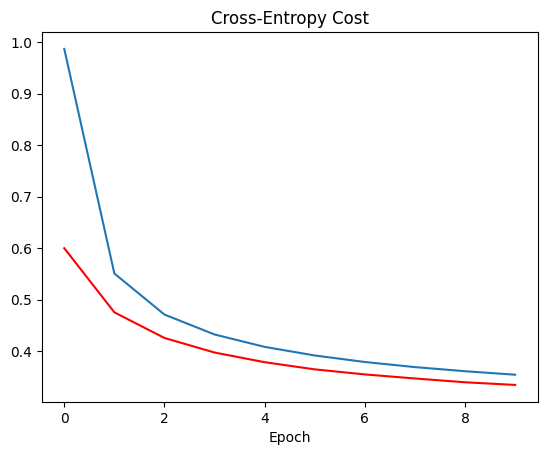

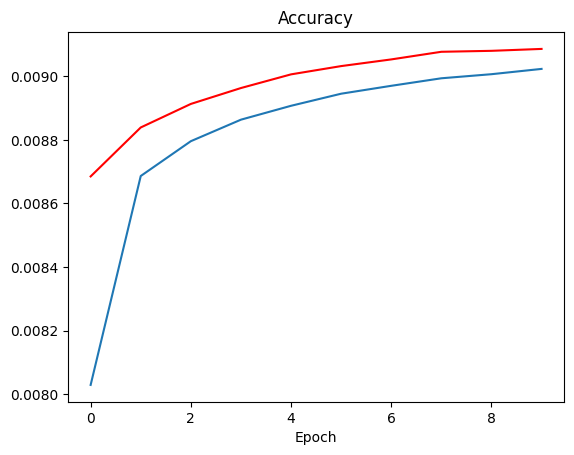

In [ ]:
plt.figure(1)
plt.plot(torch.arange(nepochs), cost_hist, "-")
plt.plot(torch.arange(nepochs), cost_hist_test, "r-")
plt.xlabel("Epoch")
plt.title("Cross-Entropy Cost")
plt.figure(2)
plt.plot(torch.arange(nepochs), acc_hist,"-")
plt.plot(torch.arange(nepochs), acc_hist_test,"r-")
plt.xlabel("Epoch")
plt.title("Accuracy")

  We obtain the same results as before.